##1.The model Architecture
The Generator uses ConvTransposed2d to "upscale" noise into an image, while the Discriminator uses Conv2d to "downsize" the image into a single probability.

In [1]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision import datasets, transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
import os

* torch: The Engine which does all the heavy math.
* nn : Short for Neural Networks. It contains the building blocks like Layers and Activation Functions.
* Adam: The "Teacher" algorithm. It looks at the weights and updates them so it performs better next time.

In [2]:
#Hyperparameters ("The secrete Sauce")


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
LEARNIG_RATE = 0.0002
batch_size = 128
image_size = 28
channels_img = 1 #MNIST is Grayscale
Noise_dim = 100
epochs = 20
feature_disc = 64 #Scale of layers in Discriminator
features_gen = 64 #Scale of layers in Generator

##2. Model Architectures


In [4]:
class Discriminator(nn.Module):
  def __init__(self, channels_img, features_d):
    super(Discriminator, self).__init__()
    self.disc = nn.Sequential(
        #Input: N x channels_img * 28 * 28
        nn.Conv2d(channels_img, features_d, kernel_size=4, stride=2, padding=1),
        nn.LeakyReLU(0.2),
        #_block(in_channels, out_channels, kernel_size, stride, padding)
        self._block(features_d, features_d * 2, 4, 2, 1),
        nn.Conv2d(features_d * 2, 1, kernel_size=7, stride=1, padding=0),
        nn.Sigmoid(),
    )

  def _block(self, in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.LeakyReLU(0.2),
    )

  def forward(self, x):
    return self.disc(x)

class Generator(nn.Module):
  def __init__(self, channels_noise, channels_img, features_g):
    super(Generator, self).__init__()
    self.net = nn.Sequential(
        #Input: N * channels_noise * 1* 1
        self._block(channels_noise, features_g * 4, 7, 1, 0), #1x1 -> 7x7
        self._block(features_g * 4, features_g * 2, 4, 2, 1), #7x7 -> 14x14
        nn.ConvTranspose2d(features_g * 2, channels_img, kernel_size=4, stride=2, padding=1),
        nn.Tanh(), #Output: 28x28
    )

  def _block(self, in_channels, out_channels, kernel_size, stride, padding):
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
    )

  def forward(self, x):
    return self.net(x)

* The Generator : The artist
* ConvTranspose2d : This is the "Upsizer." It takes a tiny 1*1 piece of noise and stretches it out into a larger grid(7*7, then 14*14, then 28*28).
* BatchNorm2d: This keeps the numbers stable. Without it, the "Artist" might get too extreme with its values, and the model would crash.
* Tanh(): This ensures the final image pixels are between -1 and 1. This is the standard range for GAN images.

* The Discriminator (The Judge):
* Conv2d: this is the scanner.It looks at the small windows of the images to find patterns(edges, loops of a '9', etc.)and shrinks the data down.
* LeakyReLU: A "smart" filter. It lets some negative values also, which helps the model learn even when it's making mistakes.
* sigmoid(): The final verdict. It outputs a number from 0 to 1. (0=Fake, 1=Real).

3. SETUP & WEIGHT INITIALIZATION


In [5]:
def initialization_weights(model):
  for m in model.modules():
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.BatchNorm2d)):
      nn.init.normal_(m.weight.data, 0.0, 0.02)

gen = Generator(Noise_dim, channels_img, features_gen).to(device)
disc = Discriminator(channels_img, feature_disc).to(device)
initialization_weights(gen)
initialization_weights(disc)

opt_gen = Adam(gen.parameters(), lr=LEARNIG_RATE, betas=(0.5, 0.999))
opt_disc = Adam(disc.parameters(), lr=LEARNIG_RATE, betas=(0.5, 0.999))
criterion = nn.BCELoss()

#Data Loading
dataloader= DataLoader(
    datasets.MNIST(root="dataset/", transform=transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]), download=True),
    batch_size=batch_size, shuffle=True
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.10MB/s]


In [6]:
# --- ADD THIS RIGHT BEFORE THE TRAINING LOOP ---
os.makedirs("day2_results", exist_ok=True)
fixed_noise = torch.randn(32, 100, 1, 1).to(device) # 32 images, 100 latent dim

print("Starting Training...")
for epoch in range(epochs):
    # ... your training code ...

    # --- ADD THIS AT THE END OF THE EPOCH (Inside the loop) ---
    with torch.no_grad():
        fake_display = gen(fixed_noise)
        save_image(fake_display, f"day2_results/epoch_{epoch+1}.png", normalize=True)


Starting Training...


* torch.randn: Creates 100 random numbers (pure static).
* 1, 1: This shapes the noise into a tiny "pixel" so the Generator's Convolutions have a starting point to expand from.

4. Training Loop

In [7]:
import os

# Create directory for results if it doesn't exist
if not os.path.exists("day2_results"):
    os.makedirs("day2_results")

# Define fixed_noise for visualization
fixed_noise = torch.randn(64, Noise_dim, 1, 1).to(device)

print("Starting Training...")
for epoch in range(epochs):
  for batch_idx, (real, _) in enumerate(dataloader):
    real = real.to(device)
    noise = torch.randn(real.shape[0], Noise_dim, 1, 1).to(device)
    fake = gen(noise)

    ###Train Discriminator: max log(D(x)) + log(1 - D(G(Z)))
    disc_real = disc(real).reshape(-1)
    loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))
    disc_fake = disc(fake.detach()).reshape(-1)
    loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))
    loss_disc = (loss_disc_real + loss_disc_fake) / 2
    disc.zero_grad()
    loss_disc.backward()
    opt_disc.step()

    ### Train Generator: min log(1- D(G(Z))) <-> max log(D(G(Z)))
    output = disc(fake).reshape(-1)
    loss_gen = criterion(output, torch.ones_like(output))
    gen.zero_grad()
    loss_gen.backward()
    opt_gen.step()

    if batch_idx % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Batch {batch_idx}/{len(dataloader)} Loss D: {loss_disc:.4f}, Loss G: {loss_gen:.4f}")

        with torch.no_grad():
            fake_display = gen(fixed_noise)
            save_image(fake_display, f"day2_results/epoch_{epoch+1}.png", normalize=True)


Starting Training...
Epoch [1/20] Batch 0/469 Loss D: 0.6927, Loss G: 0.7086
Epoch [1/20] Batch 100/469 Loss D: 0.0678, Loss G: 2.7619
Epoch [1/20] Batch 200/469 Loss D: 0.0343, Loss G: 3.7241
Epoch [1/20] Batch 300/469 Loss D: 0.1402, Loss G: 2.0358
Epoch [1/20] Batch 400/469 Loss D: 0.2248, Loss G: 1.6603
Epoch [2/20] Batch 0/469 Loss D: 0.3588, Loss G: 1.0727
Epoch [2/20] Batch 100/469 Loss D: 0.4996, Loss G: 1.8765
Epoch [2/20] Batch 200/469 Loss D: 0.4946, Loss G: 0.7992
Epoch [2/20] Batch 300/469 Loss D: 0.5578, Loss G: 1.1932
Epoch [2/20] Batch 400/469 Loss D: 0.5047, Loss G: 1.1426
Epoch [3/20] Batch 0/469 Loss D: 0.4892, Loss G: 1.3701
Epoch [3/20] Batch 100/469 Loss D: 0.4742, Loss G: 0.7142
Epoch [3/20] Batch 200/469 Loss D: 0.4643, Loss G: 1.2484
Epoch [3/20] Batch 300/469 Loss D: 0.5321, Loss G: 1.3758
Epoch [3/20] Batch 400/469 Loss D: 0.4716, Loss G: 0.7092
Epoch [4/20] Batch 0/469 Loss D: 0.4503, Loss G: 1.2271
Epoch [4/20] Batch 100/469 Loss D: 0.4422, Loss G: 1.0252
E

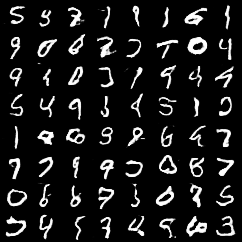

In [8]:
from IPython.display import Image
Image('day2_results/epoch_20.png')
